# Required Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
import joblib
import warnings
warnings.filterwarnings('ignore')
os.makedirs("graphs", exist_ok=True)

# Data loading and preprocessing

In [12]:
df = pd.read_csv('Bangla SMS Spam and Ham for Text Classification NLP.csv')

# কলাম ক্লিন করা (কিছু লাইনে "ham ,0" আছে)
df.columns = ['spamorham', 'label', 'sms']
df['label'] = pd.to_numeric(df['label'], errors='coerce').fillna(0).astype(int)
df = df[['sms', 'label']]  # spamorham কলাম ড্রপ

print("First 5 rows:")
print(df.head())

print("\nLabel Distribution:")
print(df['label'].value_counts())

# বাংলা টেক্সট ক্লিনিং ফাংশন (পাংচুয়েশন, অতিরিক্ত স্পেস রিমুভ)
def clean_bangla(text):
    text = str(text)   # convert to string
    text = re.sub(r'[^\u0980-\u09FF\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

df['clean_sms'] = df['sms'].apply(clean_bangla)

First 5 rows:
                                                 sms  label
0                                      আমি বললাম না       0
1                          সকালে উঠে দেখি দরজা খোলা       0
2                                      কাল দেখা হবে       0
3  আপনার মোবাইল নম্বর জিতলেন সুপার প্রাইজ! যোগাযো...      1
4  মোবাইল এক্সেসরিজে মেঘা ছাড়! যোগাযোগ করুন: ০১৭৮...      1

Label Distribution:
label
1    2055
0    1944
Name: count, dtype: int64


# Data Analysis

মেসেজ লেংথ স্ট্যাটিসটিক্স:
count    3999.000000
mean       66.482371
std        38.822922
min         0.000000
25%        42.000000
50%        55.000000
75%        80.000000
max       445.000000
Name: length, dtype: float64


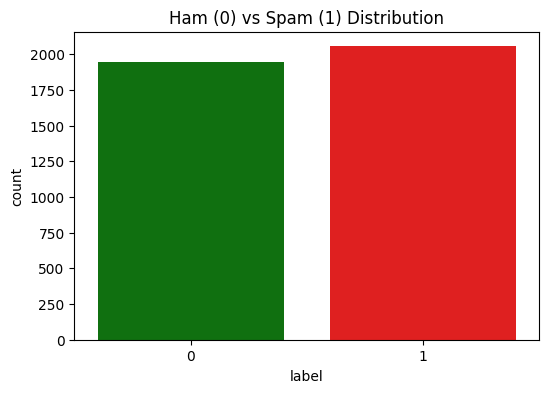

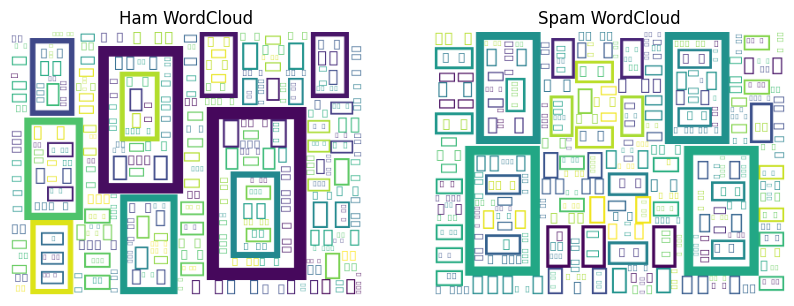

In [13]:
df['length'] = df['clean_sms'].str.len()

print("মেসেজ লেংথ স্ট্যাটিসটিক্স:")
print(df['length'].describe())

# ক্লাস ডিস্ট্রিবিউশন গ্রাফ
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette=['green', 'red'])
plt.title('Ham (0) vs Spam (1) Distribution')
plt.savefig('graphs/label_distribution.png')
plt.show()

# WordCloud (Ham ও Spam আলাদা)
ham_text = ' '.join(df[df['label']==0]['clean_sms'])
spam_text = ' '.join(df[df['label']==1]['clean_sms'])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
wc = WordCloud(font_path=None, width=400, height=300, background_color='white').generate(ham_text)
plt.imshow(wc)
plt.title('Ham WordCloud')
plt.axis('off')

plt.subplot(1,2,2)
wc = WordCloud(font_path=None, width=400, height=300, background_color='white').generate(spam_text)
plt.imshow(wc)
plt.title('Spam WordCloud')
plt.axis('off')
plt.savefig('graphs/wordcloud.png')
plt.show()

# Train‑Test Split

In [5]:
from sklearn.model_selection import train_test_split

X = df['sms']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF‑IDF Vectorization (Bangla‑friendly)

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train the Model

In [7]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


# Model Evaluation

In [8]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_vec)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.91      0.91       383
           1       0.91      0.90      0.91       392

    accuracy                           0.91       775
   macro avg       0.91      0.91      0.91       775
weighted avg       0.91      0.91      0.91       775

Confusion Matrix:

[[348  35]
 [ 38 354]]


# Predict New Bangla SMS

In [10]:
def predict_sms(text):
    text_vec = vectorizer.transform([text])
    prediction = model.predict(text_vec)[0]
    return "SPAM 🚫" if prediction == 1 else "HAM ✅"


# Example tests
print(predict_sms("আপনি ১০,০০০ টাকা লটারি জিতেছেন এখনই যোগাযোগ করুন"))
print(predict_sms("আজকে বাসায় ফিরতে একটু দেরি হবে"))

SPAM 🚫
HAM ✅


# Confusion Matrix Visualization

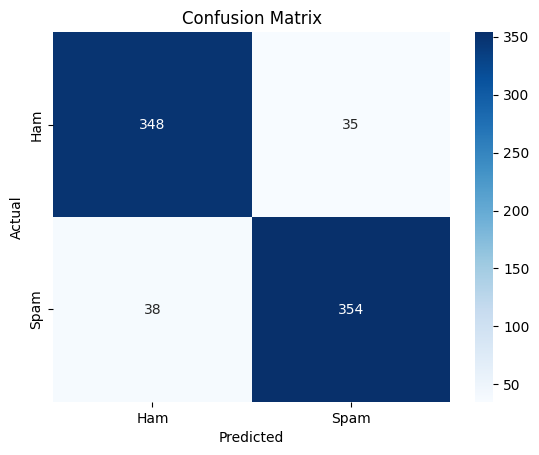

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()